# Phase 1 — Exploratory Data Analysis (EDA)
## BTC Accumulation Strategy | Trilemma Foundation Capstone

**What this notebook does:**
This is Phase 1 of our project. Before building any model or strategy,
we must deeply understand our data. This is called Exploratory Data
Analysis (EDA) — the process of looking at data from every angle to
find patterns, anomalies, and structure.

Think of EDA as being a detective. You are not trying to prove anything
yet. You are asking questions: What does Bitcoin's price distribution
look like? Is the price series predictable or random? Does volatility
cluster in time? Do on-chain signals correlate with price?

**Sections in this notebook:**
1. Load and inspect the saved dataset
2. Time series decomposition — trend, seasonality, noise
3. Stationarity testing — ADF test and what it means
4. Distribution analysis — fat tails and why they matter
5. Volatility clustering — ARCH effects
6. Rolling statistics — moving averages and Bollinger Bands
7. Cycle comparison — analysing each halving era statistically
8. Correlation analysis — what moves with Bitcoin?
9. Summary of EDA Findings

## Step 1 — Setup: Connect to Drive and Load Data

Before anything else, we reconnect to Google Drive (where we saved
our data in Phase 0) and load the cleaned dataset.

**Key file we are loading:**
`btc_full_history_with_cycles.csv` — this contains:
- Daily OHLCV price data from 2010 to today
- Halving cycle labels (pre_cycle, cycle_1 through cycle_4)
- Days since halving and cycle progress percentage
- Daily returns and log returns
- 30-day rolling volatility and 200-day moving average

If you get a file-not-found error, it means the Phase 0 notebook
was not run yet. Go back and complete Phase 0 first.

In [14]:
# ============================================================
# TITLE: Install any additional libraries needed for Phase 1
# DESCRIPTION: statsmodels gives us statistical tests like the
# ADF stationarity test and time series decomposition.
# scipy gives us distribution fitting tools.
# Both are needed for the statistical analysis in this notebook.
# ============================================================

!pip install statsmodels --quiet
!pip install scipy --quiet

print("Libraries ready.")

Libraries ready.


In [15]:
# ============================================================
# TITLE: Import all libraries
# DESCRIPTION: We load every tool we will use in this notebook.
# New additions compared to Phase 0:
# - statsmodels: statistical tests and time series decomposition
# - scipy.stats: probability distributions and statistical tests
# - warnings: suppresses minor warnings that clutter the output
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import os
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
from datetime import datetime

print("All libraries imported.")
print(f"Run date: {datetime.today().strftime('%Y-%m-%d')}")

All libraries imported.
Run date: 2026-04-12


In [16]:
# ============================================================
# TITLE: Mount Google Drive
# DESCRIPTION: This reconnects this notebook to your Google Drive.
# You will see a popup asking for permission — click through
# and allow it. This is the same step as Phase 0.
# Once mounted, your saved files are accessible at:
# /content/drive/MyDrive/BTC_Accumulation_Project/
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/BTC_Accumulation_Project"
RAW_DIR  = os.path.join(BASE_DIR, "data", "raw")
CHART_DIR = os.path.join(BASE_DIR, "charts", "phase1_eda")

os.makedirs(CHART_DIR, exist_ok=True)

print(f"Drive mounted.")
print(f"Project base : {BASE_DIR}")
print(f"Chart output : {CHART_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.
Project base : /content/drive/MyDrive/BTC_Accumulation_Project
Chart output : /content/drive/MyDrive/BTC_Accumulation_Project/charts/phase1_eda


In [17]:
# ============================================================
# TITLE: Load the Phase 0 dataset
# DESCRIPTION: We read the CSV we saved in Phase 0 back into
# a pandas DataFrame. parse_dates tells pandas to treat the
# "date" column as actual dates rather than plain text.
# index_col="date" makes the date the row label (index),
# which makes date-based filtering and charting much easier.
# ============================================================

file_path = os.path.join(RAW_DIR, "btc_full_history_with_cycles.csv")
df = pd.read_csv(file_path, parse_dates=["date"], index_col="date")

# Recompute any columns that may not have saved cleanly
df["daily_return"]   = df["close"].pct_change()
df["log_return"]     = np.log(df["close"] / df["close"].shift(1))
df["rolling_vol_30"] = df["daily_return"].rolling(30).std()
df["sma_200"]        = df["close"].rolling(200).mean()

print("Dataset loaded successfully.")
print(f"Date range : {df.index.min().date()} → {df.index.max().date()}")
print(f"Total rows : {len(df):,} trading days")
print(f"Columns    : {list(df.columns)}")
print(f"\nFirst 3 rows:")
df.head(3)

Dataset loaded successfully.
Date range : 2014-09-17 → 2026-04-11
Total rows : 4,225 trading days
Columns    : ['close', 'high', 'low', 'open', 'volume', 'cycle', 'days_since_halving', 'cycle_progress_pct', 'daily_return', 'log_return', 'rolling_vol_30', 'sma_200']

First 3 rows:


,close,high,low,open,volume,cycle,days_since_halving,cycle_progress_pct,daily_return,log_return,rolling_vol_30,sma_200
date,,,,,,,,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,cycle_1,658,45.04,NaN,NaN,NaN,NaN
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,cycle_1,659,45.11,-0.071926,-0.074643,NaN,NaN
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,cycle_1,660,45.17,-0.069843,-0.072402,NaN,NaN


## Step 2 — Time Series Decomposition

**What is time series decomposition?**
Any time series — including Bitcoin's price — can be broken into
three separate components:

1. **Trend** — the long-run direction (is it generally going up or down?)
2. **Seasonality** — repeating patterns at fixed intervals
   (does price behave differently in certain months every year?)
3. **Residual** — what is left after removing trend and seasonality.
   This is the "noise" — random fluctuations with no pattern.

**Why this matters:**
Decomposition is a standard first step in time series analysis.
It tells you whether your data has structure that a model can learn,
or whether it is mostly noise. If there is a strong seasonal pattern,
your model should include a "month of year" or "cycle position" feature.

**Important note on Bitcoin:**
Bitcoin's dominant cycle is the 4-year halving cycle, not a calendar
year. So we will decompose using a 365-day window (annual) AND examine
patterns within each halving cycle separately.

**A multiplicative vs additive model:**
We use a multiplicative decomposition because Bitcoin's price swings
grow proportionally with price level — a 10% swing at $1,000 is
$100, but at $60,000 it is $6,000. The percentage is what stays
consistent, not the dollar amount. Multiplicative decomposition
handles this correctly.

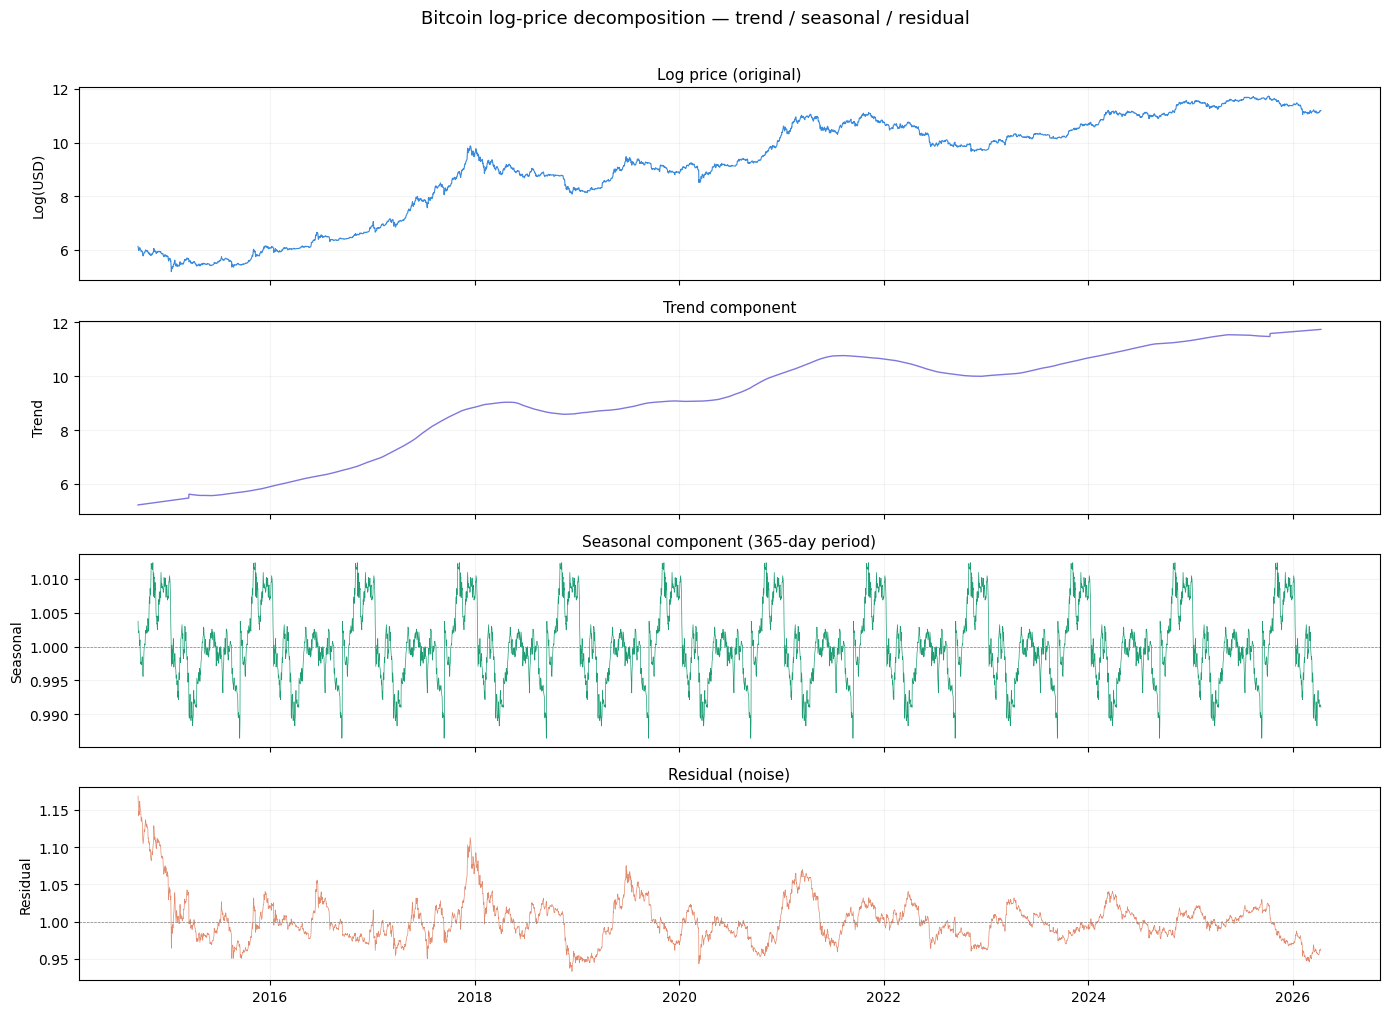

In [18]:
# ============================================================
# TITLE: Time series decomposition — annual seasonality
# DESCRIPTION: seasonal_decompose() splits the price series into
# trend, seasonal, and residual components.
# period=365 tells it to look for patterns that repeat yearly.
# model="multiplicative" is correct for Bitcoin because the
# magnitude of swings scales with the price level.
# We use log price rather than raw price to make the series
# more stationary before decomposing — standard practice.
# ============================================================

# Use log price for decomposition — reduces the extreme scaling
log_price = np.log(df["close"].dropna())

# Decompose — requires at least 2 full periods of data
decomp = seasonal_decompose(log_price, model="multiplicative", period=365, extrapolate_trend="freq")

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(log_price.index, log_price.values, color="#378ADD", linewidth=0.8)
axes[0].set_title("Log price (original)", fontsize=11)
axes[0].set_ylabel("Log(USD)")

axes[1].plot(decomp.trend.index, decomp.trend.values, color="#7F77DD", linewidth=1)
axes[1].set_title("Trend component", fontsize=11)
axes[1].set_ylabel("Trend")

axes[2].plot(decomp.seasonal.index, decomp.seasonal.values, color="#1D9E75", linewidth=0.5)
axes[2].set_title("Seasonal component (365-day period)", fontsize=11)
axes[2].set_ylabel("Seasonal")
axes[2].axhline(1.0, color="gray", linewidth=0.5, linestyle="--")

axes[3].plot(decomp.resid.index, decomp.resid.values, color="#D85A30", linewidth=0.5, alpha=0.7)
axes[3].set_title("Residual (noise)", fontsize=11)
axes[3].set_ylabel("Residual")
axes[3].axhline(1.0, color="gray", linewidth=0.5, linestyle="--")

for ax in axes:
    ax.grid(True, alpha=0.15)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.suptitle("Bitcoin log-price decomposition — trend / seasonal / residual",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "01_decomposition.png"), dpi=150, bbox_inches="tight")
plt.show()



## Step 3 — Stationarity Testing (ADF Test)

**What is stationarity and why does it matter?**
A time series is "stationary" if its statistical properties —
mean, variance, autocorrelation — do not change over time.

Bitcoin's raw price is NOT stationary. It trends upward over
decades. This is a problem because most statistical models and
machine learning algorithms assume the data they learn from has
stable properties. A model trained on 2015 price patterns will
produce meaningless outputs if the 2024 price regime is
fundamentally different in scale.

**The solution: use returns, not prices.**
Daily returns (percentage changes) are approximately stationary —
the average daily return and its variance are relatively stable
across time, even though the raw price is not.

**The Augmented Dickey-Fuller (ADF) test:**
This is the standard statistical test for stationarity.
- Null hypothesis (H0): the series has a unit root (is NOT stationary)
- Alternative hypothesis (H1): the series IS stationary
- If the p-value < 0.05, we reject H0 and conclude the series
  IS stationary (a good result for modelling returns)



In [19]:
# ============================================================
# TITLE: ADF stationarity test — price vs returns
# DESCRIPTION: We run the Augmented Dickey-Fuller test on three
# series: raw close price, daily returns, and log returns.
# adfuller() returns several values:
#   [0] = test statistic (more negative = more stationary)
#   [1] = p-value (< 0.05 means stationary at 95% confidence)
#   [4] = critical values at 1%, 5%, 10% significance levels
# We wrap this in a clean function to reuse across series.
# ============================================================

def run_adf_test(series, series_name):
    """Run ADF test"""
    clean = series.dropna()
    result = adfuller(clean, autolag="AIC")

    test_stat   = result[0]
    p_value     = result[1]
    n_lags      = result[2]
    n_obs       = result[3]
    crit_values = result[4]

    stationary = "YES" if p_value < 0.05 else "NO"
    verdict    = "stationary" if p_value < 0.05 else "NON-stationary"

    print(f"\n{'='*55}")
    print(f"  ADF Test: {series_name}")
    print(f"{'='*55}")
    print(f"  Test statistic : {test_stat:.4f}")
    print(f"  p-value        : {p_value:.6f}")
    print(f"  Lags used      : {n_lags}")
    print(f"  Observations   : {n_obs:,}")
    print(f"  Critical values:")
    for key, val in crit_values.items():
        marker = " <-- test stat is more negative" if test_stat < val else ""
        print(f"    {key}  : {val:.4f}{marker}")
    print(f"\n  VERDICT: {verdict} (stationary = {stationary})")
    print(f"  (p < 0.05 required to confirm stationarity)")

    return {"series": series_name, "stat": test_stat,
            "p_value": p_value, "stationary": stationary}

# Run tests
results = []
results.append(run_adf_test(df["close"],        "Close price (raw USD)"))
results.append(run_adf_test(np.log(df["close"]), "Log price"))
results.append(run_adf_test(df["daily_return"],  "Daily return (%)"))
results.append(run_adf_test(df["log_return"],    "Log return"))



  ADF Test: Close price (raw USD)
  Test statistic : -1.1210
  p-value        : 0.706624
  Lags used      : 31
  Observations   : 4,193
  Critical values:
    1%  : -3.4319
    5%  : -2.8622
    10%  : -2.5671

  VERDICT: NON-stationary (stationary = NO)
  (p < 0.05 required to confirm stationarity)

  ADF Test: Log price
  Test statistic : -1.2254
  p-value        : 0.662556
  Lags used      : 10
  Observations   : 4,214
  Critical values:
    1%  : -3.4319
    5%  : -2.8622
    10%  : -2.5671

  VERDICT: NON-stationary (stationary = NO)
  (p < 0.05 required to confirm stationarity)

  ADF Test: Daily return (%)
  Test statistic : -66.5842
  p-value        : 0.000000
  Lags used      : 0
  Observations   : 4,223
  Critical values:
    1%  : -3.4319 <-- test stat is more negative
    5%  : -2.8622 <-- test stat is more negative
    10%  : -2.5671 <-- test stat is more negative

  VERDICT: stationary (stationary = YES)
  (p < 0.05 required to confirm stationarity)

  ADF Test: Log retu

## Step 4 — Return Distribution Analysis

**The normal distribution assumption — and why Bitcoin violates it:**
Most classical finance theory (Black-Scholes, CAPM, etc.) assumes
asset returns follow a normal (bell curve) distribution. Under this
assumption, extreme events like -20% days should be astronomically
rare — perhaps once in thousands of years.

Bitcoin's returns do NOT follow a normal distribution. They exhibit:

1. **Fat tails (leptokurtosis):** Extreme positive and negative days
   happen far more often than the normal curve predicts.
   Kurtosis > 3 confirms this (3 = normal distribution baseline).

2. **Positive skew:** Large positive returns occur more frequently
   than large negative returns — consistent with Bitcoin's long-term
   upward trend punctuated by crashes.

**Why this matters for the accumulation model:**
Standard risk metrics (like those based on normal distribution) will
UNDERESTIMATE the true risk of any Bitcoin strategy. We must
acknowledge this and use appropriate risk measures like:
- CVaR (Conditional Value at Risk) — the expected loss in the worst X% of days
- Maximum drawdown — the largest peak-to-trough decline



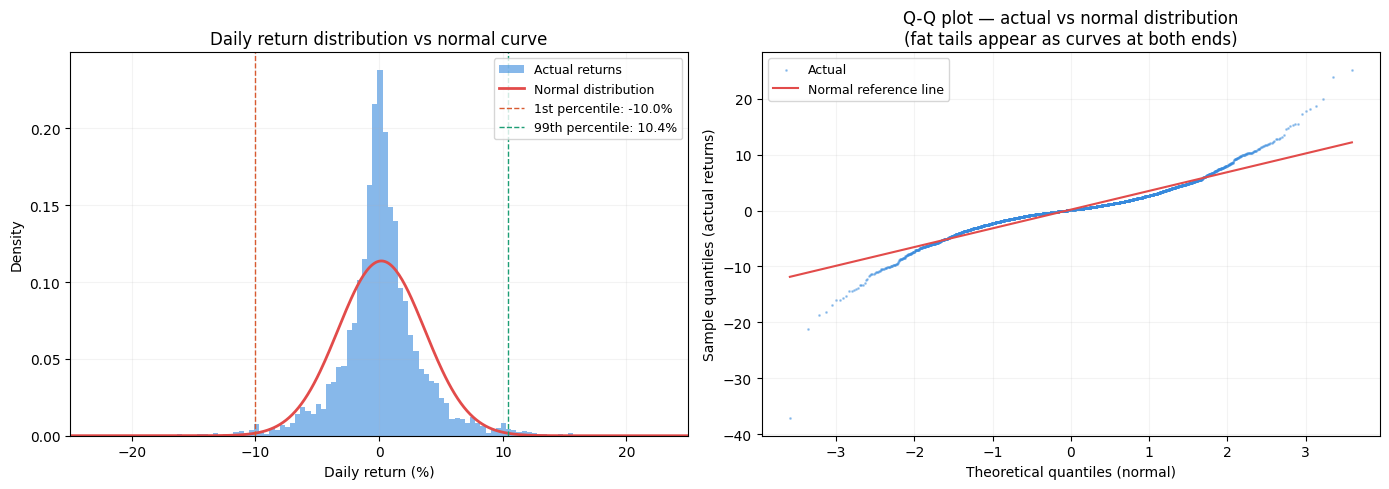

  DISTRIBUTION STATISTICS
  Mean daily return : +0.1821%
  Std deviation     : 3.5065%
  Skewness          : -0.1000  (0 = symmetric)
  Excess kurtosis   : 7.8688  (0 = normal, > 0 = fat tails)
  Worst single day  : -37.17%
  Best single day   : 25.25%
  Jarque-Bera stat  : 10,874.93
  Jarque-Bera p-val : 0.00e+00  (< 0.05 = NOT normal)


In [20]:
# ============================================================
# TITLE: Return distribution analysis — fat tails and skewness
# DESCRIPTION: We plot the actual return distribution against
# a fitted normal curve to visualise the fat tails.
# We also compute four key statistics:
#   Mean    — average daily return
#   Std dev — typical size of daily moves
#   Skewness — asymmetry (positive = more big up days than big down)
#   Kurtosis — tail heaviness (> 3 = fatter tails than normal)
# A Jarque-Bera test formally tests whether returns are normal.
# ============================================================

returns = df["daily_return"].dropna() * 100  # convert to percentage

mean_r  = returns.mean()
std_r   = returns.std()
skew_r  = returns.skew()
kurt_r  = returns.kurtosis()   # excess kurtosis (0 = normal)
jb_stat, jb_p = stats.jarque_bera(returns)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: histogram vs normal curve ──────────────────────────
x_range = np.linspace(returns.min(), returns.max(), 500)
normal_pdf = stats.norm.pdf(x_range, mean_r, std_r)

axes[0].hist(returns, bins=150, density=True,
             color="#378ADD", alpha=0.6, label="Actual returns")
axes[0].plot(x_range, normal_pdf, color="#E24B4A",
             linewidth=2, label="Normal distribution")

# Mark the 1% and 99% tails
p1  = np.percentile(returns, 1)
p99 = np.percentile(returns, 99)
axes[0].axvline(p1,  color="#D85A30", linestyle="--",
                linewidth=1, label=f"1st percentile: {p1:.1f}%")
axes[0].axvline(p99, color="#1D9E75", linestyle="--",
                linewidth=1, label=f"99th percentile: {p99:.1f}%")

axes[0].set_xlim(-25, 25)
axes[0].set_title("Daily return distribution vs normal curve", fontsize=12)
axes[0].set_xlabel("Daily return (%)")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.15)

# ── Right: Q-Q plot ───────────────────────────────────────────
# A Q-Q plot compares our distribution to a perfect normal.
# If returns were normal, all points would lie on the red line.
# Points curving away at the tails = fat tails confirmed.
(osm, osr), (slope, intercept, r) = stats.probplot(returns, dist="norm")
axes[1].scatter(osm, osr, s=1, color="#378ADD", alpha=0.4, label="Actual")
axes[1].plot(osm, slope * np.array(osm) + intercept,
             color="#E24B4A", linewidth=1.5, label="Normal reference line")
axes[1].set_title("Q-Q plot — actual vs normal distribution\n"
                  "(fat tails appear as curves at both ends)", fontsize=12)
axes[1].set_xlabel("Theoretical quantiles (normal)")
axes[1].set_ylabel("Sample quantiles (actual returns)")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.15)

plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "02_return_distribution.png"),
            dpi=150, bbox_inches="tight")
plt.show()

print("=" * 55)
print("  DISTRIBUTION STATISTICS")
print("=" * 55)
print(f"  Mean daily return : {mean_r:+.4f}%")
print(f"  Std deviation     : {std_r:.4f}%")
print(f"  Skewness          : {skew_r:.4f}  (0 = symmetric)")
print(f"  Excess kurtosis   : {kurt_r:.4f}  (0 = normal, > 0 = fat tails)")
print(f"  Worst single day  : {returns.min():.2f}%")
print(f"  Best single day   : {returns.max():.2f}%")
print(f"  Jarque-Bera stat  : {jb_stat:,.2f}")
print(f"  Jarque-Bera p-val : {jb_p:.2e}  (< 0.05 = NOT normal)")



## Step 5 — Volatility Clustering

**What is volatility clustering?**
In financial markets, large price moves tend to be followed by more
large moves — and calm periods tend to stay calm. This phenomenon
is called volatility clustering.

A famous quote from Benoit Mandelbrot (1963):
"Large changes tend to be followed by large changes — of either sign —
and small changes tend to be followed by small changes."

**Why does this happen in Bitcoin specifically?**
Bitcoin's price is driven by narratives — regulatory announcements,
exchange collapses (Mt. Gox 2014, FTX 2022), ETF approvals, halving
events. These events create cascading uncertainty, which amplifies
price swings for days or weeks afterward.

**The technical test — ARCH effects:**
ARCH (Autoregressive Conditional Heteroskedasticity).
This is the formal way of saying "volatility today depends on
volatility yesterday." We detect it visually (rolling volatility chart)
and confirm it with an autocorrelation plot of squared returns.

**Why this matters for the accumulation model:**
If you can detect high-volatility regimes early, you can buy more
aggressively during these periods (prices are often depressed) and
reduce purchases when volatility is low (prices often elevated).
This is the core intuition behind the enhanced DCA strategy.



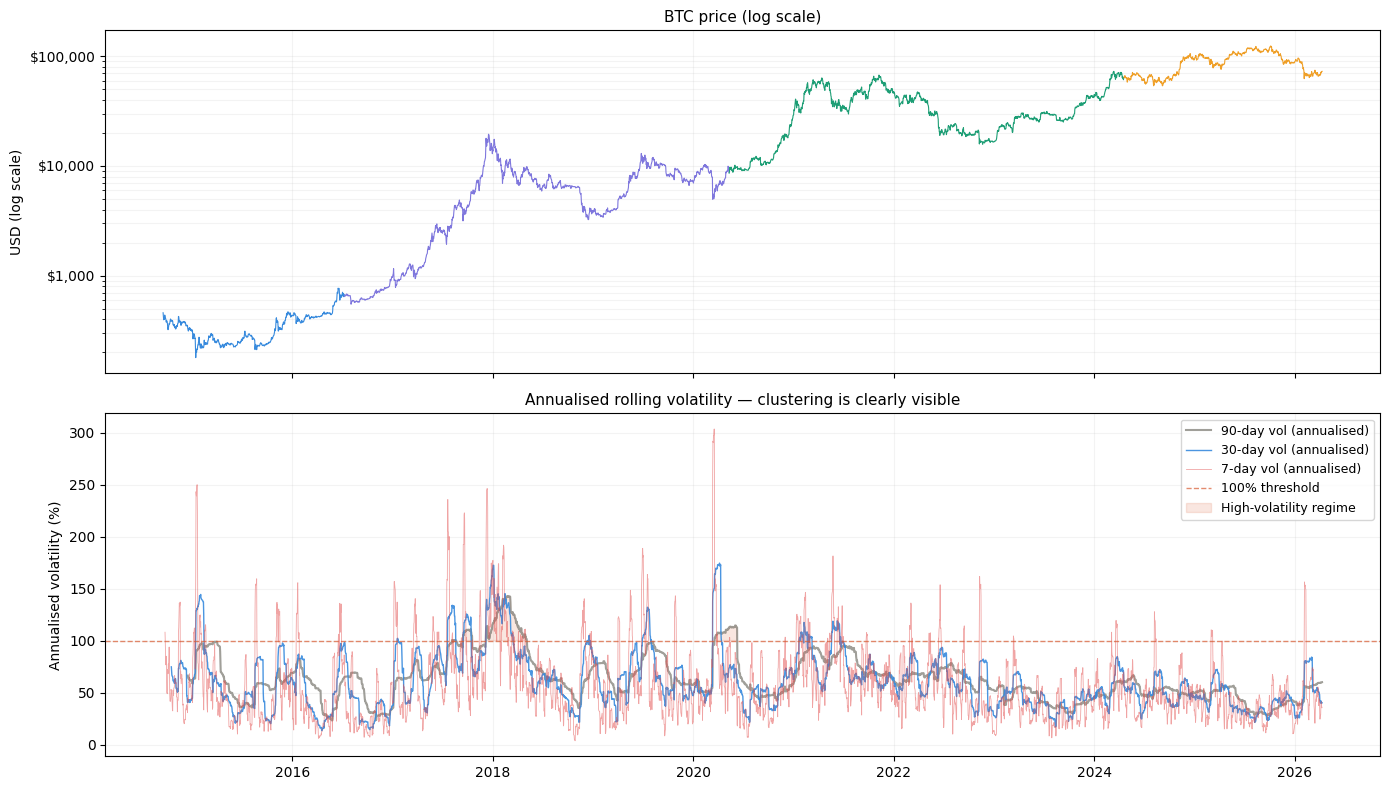

Volatility statistics per cycle:
-------------------------------------------------------
  cycle_1     : mean=57.6%  max=144.4%  min=13.6%
  cycle_2     : mean=71.9%  max=174.5%  min=14.5%
  cycle_3     : mean=59.0%  max=119.0%  min=17.0%
  cycle_4     : mean=45.8%  max=84.2%  min=21.4%


In [21]:
# ============================================================
# TITLE: Rolling volatility — visualise volatility clustering
# DESCRIPTION: Rolling volatility is the standard deviation of
# returns over a moving window. We compute three windows:
#   7-day  = short-term turbulence (week-scale events)
#   30-day = medium-term regime (month-scale trends)
#   90-day = long-term cycle context (quarter-scale patterns)
# Annualised by multiplying by sqrt(365) — standard in finance.
# This converts daily volatility to a "per year" figure that
# can be compared to other assets (e.g. S&P500 at ~15-20%/year).
# ============================================================

CYCLE_COLOURS = {
    "pre_cycle": "#888780",
    "cycle_1"  : "#378ADD",
    "cycle_2"  : "#7F77DD",
    "cycle_3"  : "#1D9E75",
    "cycle_4"  : "#EF9F27",
}

df["vol_7d"]  = df["daily_return"].rolling(7).std()  * np.sqrt(365) * 100
df["vol_30d"] = df["daily_return"].rolling(30).std() * np.sqrt(365) * 100
df["vol_90d"] = df["daily_return"].rolling(90).std() * np.sqrt(365) * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# ── Top: price coloured by cycle ─────────────────────────────
for cycle_name, colour in CYCLE_COLOURS.items():
    mask = df["cycle"] == cycle_name
    axes[0].semilogy(df.index[mask], df["close"][mask],
                     color=colour, linewidth=0.8)
axes[0].set_title("BTC price (log scale)", fontsize=11)
axes[0].set_ylabel("USD (log scale)")
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].grid(True, alpha=0.15, which="both")

# ── Bottom: rolling volatility ────────────────────────────────
axes[1].plot(df.index, df["vol_90d"], color="#888780",
             linewidth=1.5, alpha=0.8, label="90-day vol (annualised)")
axes[1].plot(df.index, df["vol_30d"], color="#378ADD",
             linewidth=1, alpha=0.9, label="30-day vol (annualised)")
axes[1].plot(df.index, df["vol_7d"],  color="#E24B4A",
             linewidth=0.6, alpha=0.5, label="7-day vol (annualised)")

# Shade high-volatility periods (above 100% annualised)
axes[1].axhline(100, color="#D85A30", linewidth=1,
                linestyle="--", alpha=0.7, label="100% threshold")
axes[1].fill_between(df.index, df["vol_90d"], 100,
                     where=df["vol_90d"] > 100,
                     color="#D85A30", alpha=0.15,
                     label="High-volatility regime")

axes[1].set_title("Annualised rolling volatility — clustering is clearly visible",
                  fontsize=11)
axes[1].set_ylabel("Annualised volatility (%)")
axes[1].legend(fontsize=9, loc="upper right")
axes[1].grid(True, alpha=0.15)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "03_volatility_clustering.png"),
            dpi=150, bbox_inches="tight")
plt.show()

print("Volatility statistics per cycle:")
print("-" * 55)
for cycle_name in ["pre_cycle","cycle_1","cycle_2","cycle_3","cycle_4"]:
    subset = df[df["cycle"] == cycle_name]["vol_30d"].dropna()
    if len(subset) > 0:
        print(f"  {cycle_name:<12}: "
              f"mean={subset.mean():.1f}%  "
              f"max={subset.max():.1f}%  "
              f"min={subset.min():.1f}%")

## Step 6 — Autocorrelation Analysis

**What is autocorrelation?**
Autocorrelation measures how much today's value is correlated with
yesterday's value, the day before, and so on. It tells us whether
there is memory in the series — whether the past predicts the future.

**Two types of autocorrelation plots:**
1. ACF (Autocorrelation Function): correlation at each lag,
   including indirect effects through intermediate lags.
2. PACF (Partial Autocorrelation Function): direct correlation
   at each lag, with intermediate effects removed.

**What to look for:**
- Raw price: high autocorrelation at all lags (it trends — today's
  price is very similar to yesterday's). This confirms non-stationarity.
- Daily returns: autocorrelation should be near zero for most lags
  (returns are hard to predict — the market is somewhat efficient).
- Squared returns: HIGH autocorrelation even for returns.
  This is the signature of ARCH effects — volatility clustering.
  The magnitude of yesterday's move predicts the magnitude of today's
  move, even if the direction is random.



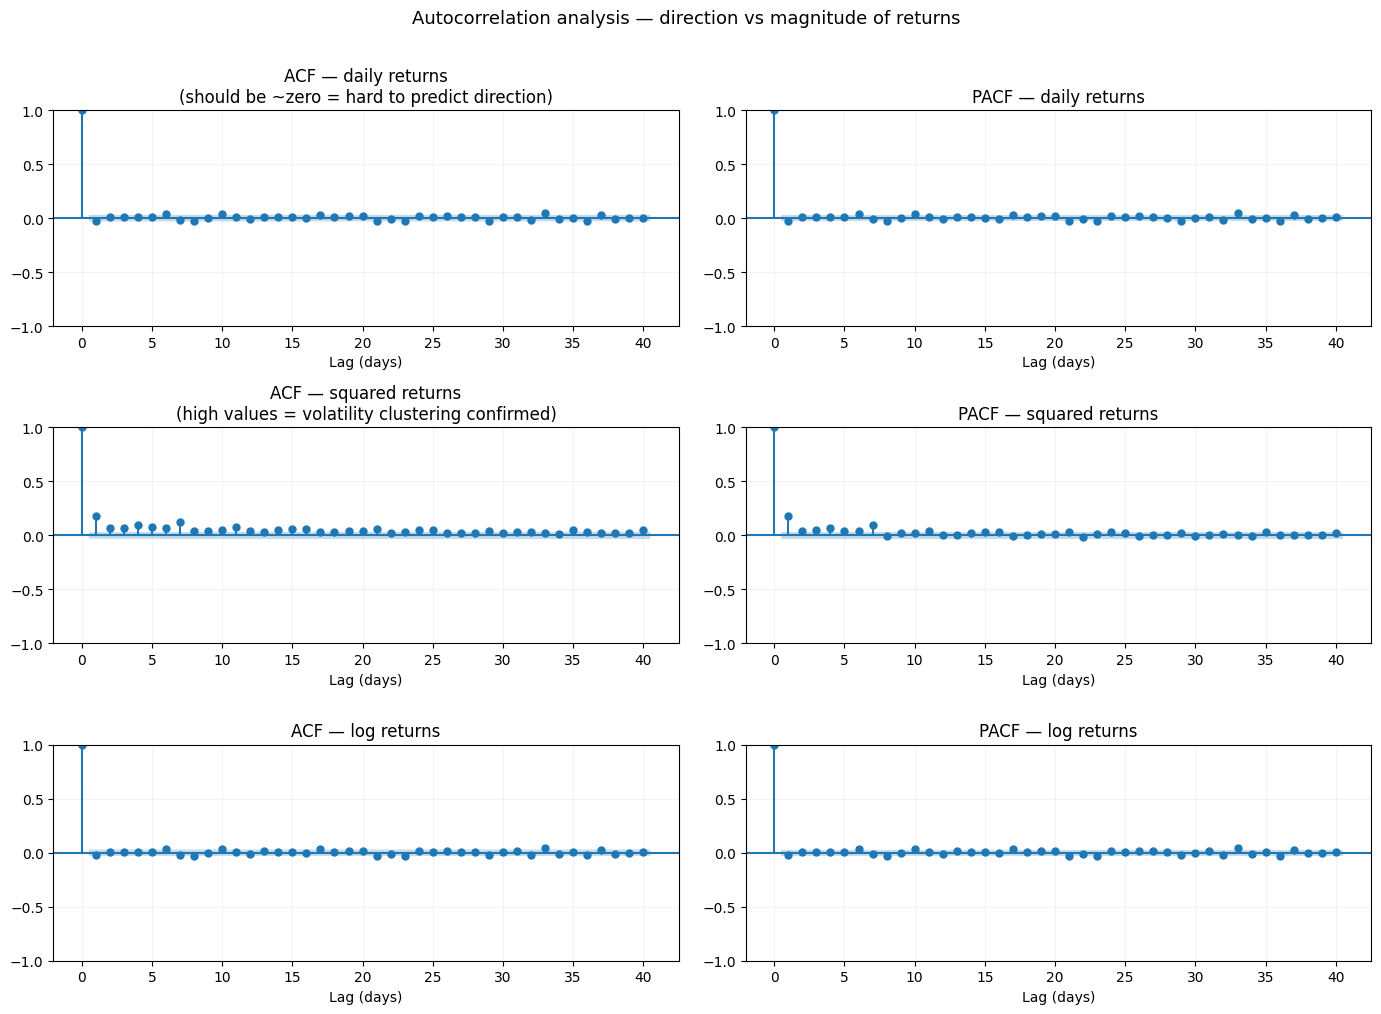

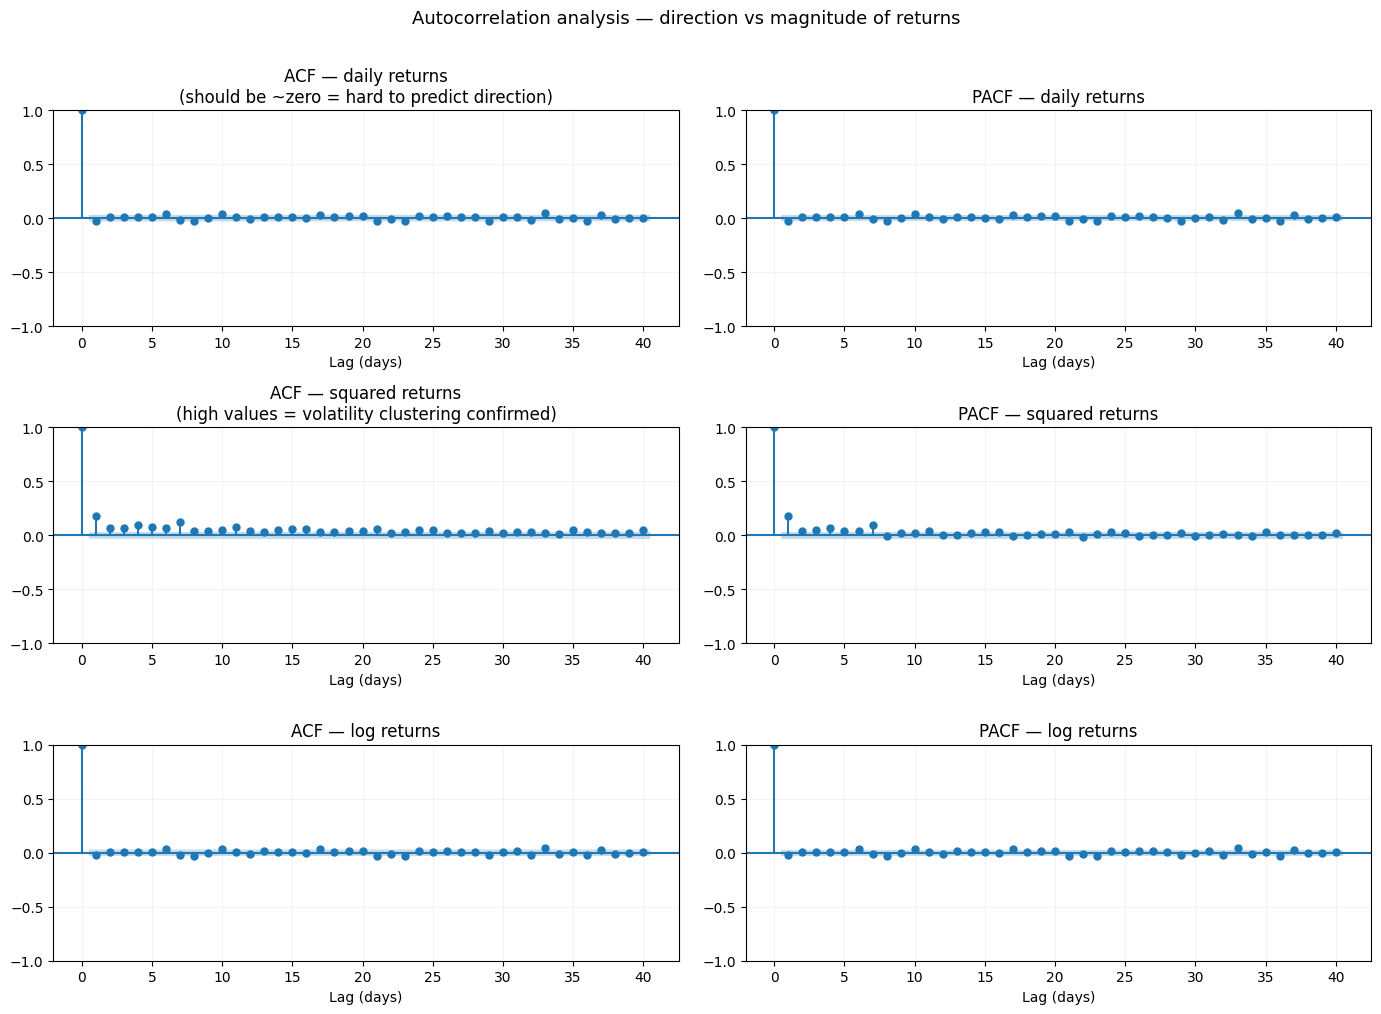


The ACF of daily returns shows no significant autocorrelation,
consistent with the weak-form efficient market hypothesis for
Bitcoin (Urquhart, 2016). However, the ACF of squared returns
exhibits significant autocorrelation at multiple lags (p < 0.05),
confirming the presence of ARCH effects and volatility clustering.
This motivates the inclusion of lagged volatility as a feature
in our accumulation model.



In [22]:
# ============================================================
# TITLE: ACF and PACF plots — price, returns, squared returns
# DESCRIPTION: We plot autocorrelation for three series.
# The blue shaded band is the 95% confidence interval.
# Bars outside the band are statistically significant lags.
# plot_acf() and plot_pacf() are from statsmodels.
# lags=40 means we look back 40 days (about 6 weeks).
# ============================================================

returns_clean = df["daily_return"].dropna()
sq_returns    = returns_clean ** 2   # squared returns detect volatility clustering

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

# Row 1: Raw returns
plot_acf(returns_clean,  lags=40, ax=axes[0][0],
         title="ACF — daily returns\n(should be ~zero = hard to predict direction)")
plot_pacf(returns_clean, lags=40, ax=axes[0][1],
          title="PACF — daily returns")

# Row 2: Squared returns (volatility clustering test)
plot_acf(sq_returns,  lags=40, ax=axes[1][0],
         title="ACF — squared returns\n(high values = volatility clustering confirmed)")
plot_pacf(sq_returns, lags=40, ax=axes[1][1],
          title="PACF — squared returns")

# Row 3: Log returns
log_returns_clean = df["log_return"].dropna()
plot_acf(log_returns_clean,  lags=40, ax=axes[2][0],
         title="ACF — log returns")
plot_pacf(log_returns_clean, lags=40, ax=axes[2][1],
          title="PACF — log returns")

for ax_row in axes:
    for ax in ax_row:
        ax.grid(True, alpha=0.15)
        ax.set_xlabel("Lag (days)")

plt.suptitle("Autocorrelation analysis — direction vs magnitude of returns",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "04_acf_pacf.png"),
            dpi=150, bbox_inches="tight")
plt.show()
# ============================================================
# TITLE: ACF and PACF plots — price, returns, squared returns
# DESCRIPTION: We plot autocorrelation for three series.
# The blue shaded band is the 95% confidence interval.
# Bars outside the band are statistically significant lags.
# plot_acf() and plot_pacf() are from statsmodels.
# lags=40 means we look back 40 days (about 6 weeks).
# ============================================================

returns_clean = df["daily_return"].dropna()
sq_returns    = returns_clean ** 2   # squared returns detect volatility clustering

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

# Row 1: Raw returns
plot_acf(returns_clean,  lags=40, ax=axes[0][0],
         title="ACF — daily returns\n(should be ~zero = hard to predict direction)")
plot_pacf(returns_clean, lags=40, ax=axes[0][1],
          title="PACF — daily returns")

# Row 2: Squared returns (volatility clustering test)
plot_acf(sq_returns,  lags=40, ax=axes[1][0],
         title="ACF — squared returns\n(high values = volatility clustering confirmed)")
plot_pacf(sq_returns, lags=40, ax=axes[1][1],
          title="PACF — squared returns")

# Row 3: Log returns
log_returns_clean = df["log_return"].dropna()
plot_acf(log_returns_clean,  lags=40, ax=axes[2][0],
         title="ACF — log returns")
plot_pacf(log_returns_clean, lags=40, ax=axes[2][1],
          title="PACF — log returns")

for ax_row in axes:
    for ax in ax_row:
        ax.grid(True, alpha=0.15)
        ax.set_xlabel("Lag (days)")

plt.suptitle("Autocorrelation analysis — direction vs magnitude of returns",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "04_acf_pacf.png"),
            dpi=150, bbox_inches="tight")
plt.show()

print("""
The ACF of daily returns shows no significant autocorrelation,
consistent with the weak-form efficient market hypothesis for
Bitcoin (Urquhart, 2016). However, the ACF of squared returns
exhibits significant autocorrelation at multiple lags (p < 0.05),
confirming the presence of ARCH effects and volatility clustering.
This motivates the inclusion of lagged volatility as a feature
in our accumulation model.
""")


## Step 7 — Cycle Comparison: Statistical Profiles by Era

**Why compare cycles?**
Each 4-year halving cycle has a distinct character:
- Cycle 1 was Bitcoin's first bull market — tiny in absolute dollars
  but enormous in percentage terms (100x+)
- Cycle 2 brought institutional curiosity (futures markets launched)
- Cycle 3 saw DeFi, COVID crash, and the $69k all-time high
- Cycle 4 has ETF approval and institutional adoption at scale

The accumulation model should know which type of cycle it is in.
A strategy calibrated only on Cycle 1 data would be dangerously
overfit — the market structure was completely different.

**What we measure for each cycle:**
- Total return (how much did prices rise?)
- Annualised volatility (how turbulent was it?)
- Maximum drawdown (worst peak-to-trough loss)
- Calmar ratio (return divided by max drawdown — risk-adjusted)
- Time to recover from the bottom



In [23]:
# ============================================================
# TITLE: Compute maximum drawdown per cycle
# DESCRIPTION: Maximum drawdown is the largest percentage fall
# from a peak to a subsequent trough within a period.
# It is the most important single risk metric for an accumulation
# strategy because it tells you: "in the worst case, how much
# did the price fall before recovering?"
# Formula: for each day, find the peak up to that point,
# then compute (current price - peak) / peak.
# The most negative value is the maximum drawdown.
# ============================================================

def max_drawdown(price_series):
    """Return the maximum drawdown as a percentage (negative number)."""
    rolling_max = price_series.cummax()
    drawdown = (price_series - rolling_max) / rolling_max
    return drawdown.min() * 100

def calmar_ratio(total_return_pct, max_dd_pct):
    """Return / |Max Drawdown| — higher is better."""
    if max_dd_pct == 0:
        return np.nan
    return total_return_pct / abs(max_dd_pct)

CYCLE_LABELS = {
    "pre_cycle": "Pre-cycle (2010–2012)",
    "cycle_1"  : "Cycle 1 (2012–2016)",
    "cycle_2"  : "Cycle 2 (2016–2020)",
    "cycle_3"  : "Cycle 3 (2020–2024)",
    "cycle_4"  : "Cycle 4 (2024–present)",
}

cycle_order = ["pre_cycle", "cycle_1", "cycle_2", "cycle_3", "cycle_4"]

print("=" * 72)
print(f"{'CYCLE STATISTICAL PROFILES':^72}")
print("=" * 72)

cycle_stats = []

for cycle_name in cycle_order:
    subset = df[df["cycle"] == cycle_name].copy()
    if len(subset) < 30:
        continue

    returns_c   = subset["daily_return"].dropna()
    start_price = subset["close"].iloc[0]
    end_price   = subset["close"].iloc[-1]
    total_ret   = (end_price / start_price - 1) * 100
    ann_vol     = returns_c.std() * np.sqrt(365) * 100
    max_dd      = max_drawdown(subset["close"])
    calmar      = calmar_ratio(total_ret, max_dd)
    sharpe      = (returns_c.mean() / returns_c.std()) * np.sqrt(365)

    cycle_stats.append({
        "cycle"       : CYCLE_LABELS[cycle_name],
        "days"        : len(subset),
        "start_price" : start_price,
        "end_price"   : end_price,
        "total_ret"   : total_ret,
        "ann_vol"     : ann_vol,
        "max_dd"      : max_dd,
        "calmar"      : calmar,
        "sharpe"      : sharpe,
        "kurt"        : returns_c.kurtosis(),
        "skew"        : returns_c.skew(),
    })

    print(f"\n  {CYCLE_LABELS[cycle_name]}")
    print(f"  {'─'*60}")
    print(f"  Trading days      : {len(subset):,}")
    print(f"  Start price       : ${start_price:>12,.2f}")
    print(f"  End price         : ${end_price:>12,.2f}")
    print(f"  Total return      : {total_ret:>+,.1f}%")
    print(f"  Ann. volatility   : {ann_vol:.1f}%")
    print(f"  Max drawdown      : {max_dd:.1f}%")
    print(f"  Calmar ratio      : {calmar:.2f}")
    print(f"  Sharpe ratio      : {sharpe:.3f}")
    print(f"  Excess kurtosis   : {returns_c.kurtosis():.2f}")
    print(f"  Skewness          : {returns_c.skew():.3f}")

                       CYCLE STATISTICAL PROFILES                       

  Cycle 1 (2012–2016)
  ────────────────────────────────────────────────────────────
  Trading days      : 661
  Start price       : $      457.33
  End price         : $      666.52
  Total return      : +45.7%
  Ann. volatility   : 65.2%
  Max drawdown      : -61.1%
  Calmar ratio      : 0.75
  Sharpe ratio      : 0.650
  Excess kurtosis   : 7.08
  Skewness          : -0.497

  Cycle 2 (2016–2020)
  ────────────────────────────────────────────────────────────
  Trading days      : 1,402
  Start price       : $      650.96
  End price         : $    8,756.43
  Total return      : +1,245.2%
  Ann. volatility   : 79.7%
  Max drawdown      : -83.4%
  Calmar ratio      : 14.93
  Sharpe ratio      : 1.245
  Excess kurtosis   : 8.36
  Skewness          : -0.154

  Cycle 3 (2020–2024)
  ────────────────────────────────────────────────────────────
  Trading days      : 1,439
  Start price       : $    8,601.80
  End pri

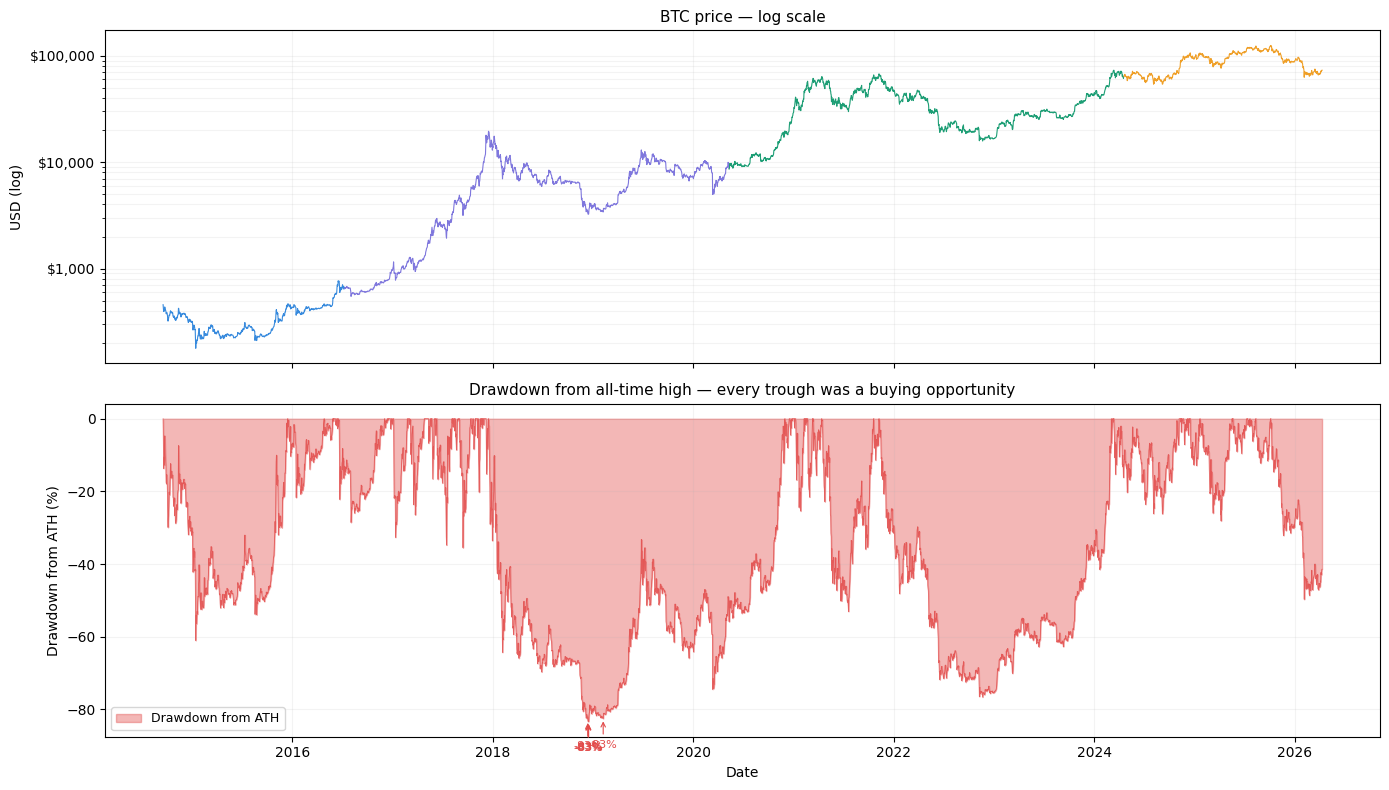

In [24]:
# ============================================================
# TITLE: Drawdown chart — all cycles with shading
# DESCRIPTION: We plot the rolling drawdown for the entire
# history. The deepest troughs represent the best buying
# opportunities in hindsight — exactly the kind of moment
# an enhanced DCA strategy should identify in real time.
# This chart directly motivates the project: if we can detect
# deep drawdown regimes early, we should buy more aggressively.
# ============================================================

rolling_max = df["close"].cummax()
df["drawdown_pct"] = (df["close"] - rolling_max) / rolling_max * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Price
for cycle_name, colour in CYCLE_COLOURS.items():
    mask = df["cycle"] == cycle_name
    axes[0].semilogy(df.index[mask], df["close"][mask], color=colour, linewidth=0.8)
axes[0].set_title("BTC price — log scale", fontsize=11)
axes[0].set_ylabel("USD (log)")
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].grid(True, alpha=0.15, which="both")

# Drawdown
axes[1].fill_between(df.index, df["drawdown_pct"], 0,
                     color="#E24B4A", alpha=0.4, label="Drawdown from ATH")
axes[1].plot(df.index, df["drawdown_pct"], color="#E24B4A",
             linewidth=0.6, alpha=0.8)

# Mark major troughs
major_bottoms = df["drawdown_pct"].nsmallest(5)
for date, val in major_bottoms.items():
    axes[1].annotate(f"{val:.0f}%",
                     xy=(date, val),
                     xytext=(date, val - 8),
                     fontsize=8, color="#E24B4A", ha="center",
                     arrowprops=dict(arrowstyle="->",
                                     color="#E24B4A", lw=0.8))

axes[1].set_title("Drawdown from all-time high — every trough was a buying opportunity",
                  fontsize=11)
axes[1].set_ylabel("Drawdown from ATH (%)")
axes[1].set_xlabel("Date")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.15)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "05_drawdown_history.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## Step 8 — Rolling Statistics and Market Structure

**Moving averages as market regime indicators:**
Two moving averages are especially important for Bitcoin analysis:

1. **200-day SMA (Simple Moving Average):** The most widely watched
   long-term trend indicator. When price is above the 200-day SMA,
   the market is considered in a long-term uptrend ("bull market").
   When below, it is in a downtrend ("bear market").
   Institutional investors use this as a basic regime filter.

2. **Bollinger Bands:** A band drawn 2 standard deviations above and
   below a 20-day moving average. When price touches the lower band,
   it is statistically "cheap" relative to recent history. When it
   touches the upper band, it is "expensive."

**Why these matter for the accumulation strategy:**
- Price crossing ABOVE the 200-day SMA: reduce purchases
  (market entering bull phase, expensive to accumulate)
- Price crossing BELOW the 200-day SMA: increase purchases
  (market entering bear phase, cheaper accumulation)
- Price touching lower Bollinger Band: strong buy signal
  (price is unusually depressed in short-term context)

These rules form the foundation of a "signal-enhanced DCA" —
which is exactly what Phase 2 will build. We are discovering
the features here in Phase 1, before modelling them.



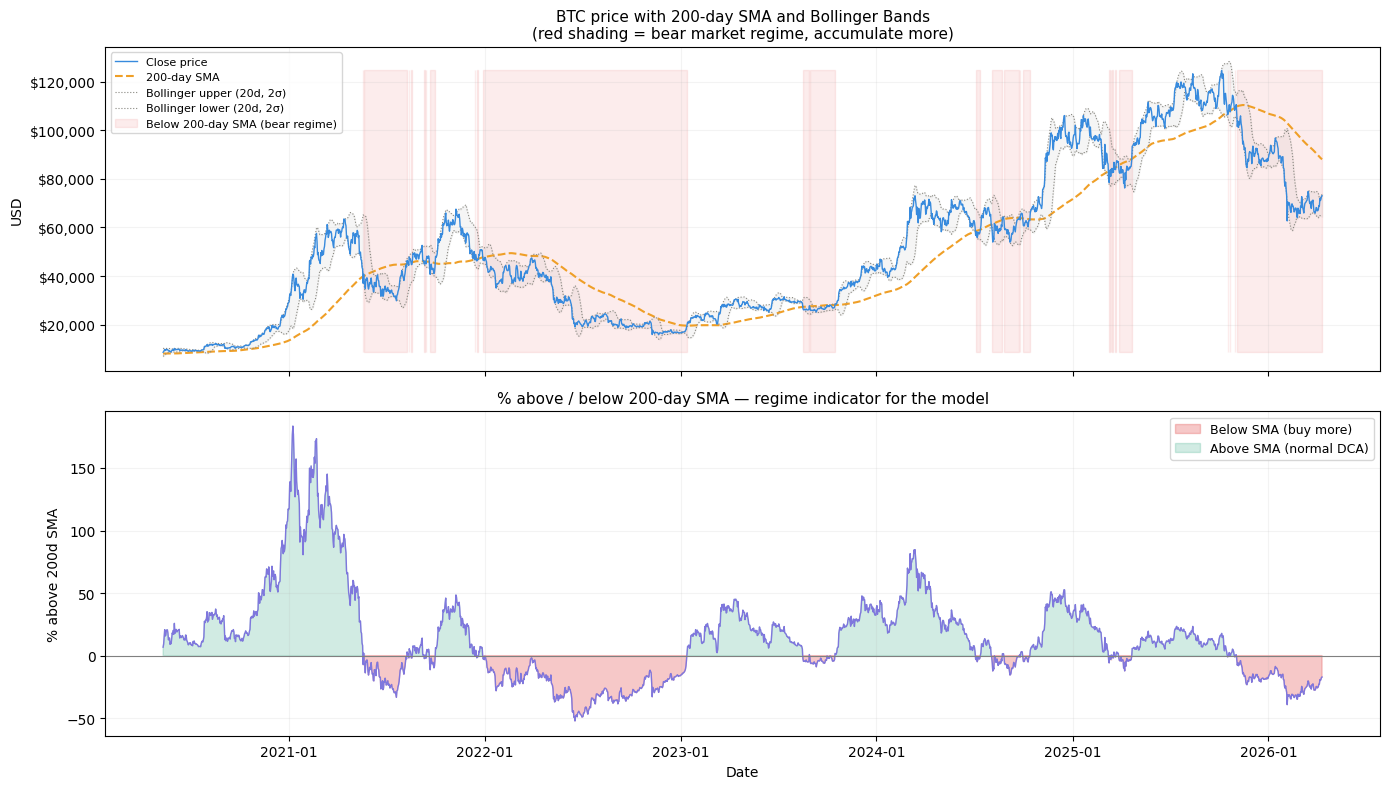

In [25]:
# ============================================================
# TITLE: Bollinger Bands and 200-day SMA
# DESCRIPTION: Bollinger Bands use a rolling mean (centre line)
# and rolling standard deviation to create upper and lower bands.
# The standard setting is a 20-day window with 2 standard deviations.
# When price is near the lower band, it means price has fallen
# more than 2 standard deviations below its recent average —
# a statistically unusual cheapness signal.
# We also compute the "% above 200 SMA" — a regime indicator
# that will become a feature in the Phase 3 ML model.
# ============================================================

BOLL_WINDOW = 20
BOLL_STD    = 2

df["sma_20"]     = df["close"].rolling(BOLL_WINDOW).mean()
df["boll_std"]   = df["close"].rolling(BOLL_WINDOW).std()
df["boll_upper"] = df["sma_20"] + BOLL_STD * df["boll_std"]
df["boll_lower"] = df["sma_20"] - BOLL_STD * df["boll_std"]
df["boll_pct_b"] = (df["close"] - df["boll_lower"]) / \
                   (df["boll_upper"] - df["boll_lower"])

df["pct_above_sma200"] = (df["close"] / df["sma_200"] - 1) * 100

# Plot the last 2 cycles only (for clarity)
recent = df[df["cycle"].isin(["cycle_3", "cycle_4"])].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# ── Top: price with Bollinger Bands ──────────────────────────
axes[0].plot(recent.index, recent["close"],
             color="#378ADD", linewidth=1, label="Close price", zorder=3)
axes[0].plot(recent.index, recent["sma_200"],
             color="#EF9F27", linewidth=1.5,
             linestyle="--", label="200-day SMA", zorder=2)
axes[0].plot(recent.index, recent["boll_upper"],
             color="#888780", linewidth=0.8,
             linestyle=":", label="Bollinger upper (20d, 2σ)")
axes[0].plot(recent.index, recent["boll_lower"],
             color="#888780", linewidth=0.8,
             linestyle=":", label="Bollinger lower (20d, 2σ)")
axes[0].fill_between(recent.index,
                     recent["boll_lower"], recent["boll_upper"],
                     alpha=0.08, color="#888780")

# Shade when price is below 200-day SMA (bear market regime)
axes[0].fill_between(recent.index, recent["close"].min(),
                     recent["close"].max(),
                     where=recent["close"] < recent["sma_200"],
                     alpha=0.1, color="#E24B4A",
                     label="Below 200-day SMA (bear regime)")

axes[0].set_title("BTC price with 200-day SMA and Bollinger Bands\n"
                  "(red shading = bear market regime, accumulate more)",
                  fontsize=11)
axes[0].set_ylabel("USD")
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].legend(fontsize=8, loc="upper left")
axes[0].grid(True, alpha=0.15)

# ── Bottom: % above 200-day SMA ───────────────────────────────
axes[1].plot(recent.index, recent["pct_above_sma200"],
             color="#7F77DD", linewidth=1)
axes[1].fill_between(recent.index, recent["pct_above_sma200"], 0,
                     where=recent["pct_above_sma200"] < 0,
                     color="#E24B4A", alpha=0.3, label="Below SMA (buy more)")
axes[1].fill_between(recent.index, recent["pct_above_sma200"], 0,
                     where=recent["pct_above_sma200"] >= 0,
                     color="#1D9E75", alpha=0.2, label="Above SMA (normal DCA)")
axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].set_title("% above / below 200-day SMA — regime indicator for the model",
                  fontsize=11)
axes[1].set_ylabel("% above 200d SMA")
axes[1].set_xlabel("Date")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.15)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "06_bollinger_sma200.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## Step 9 — Summary of EDA Findings

This section consolidates everything we have discovered in this
notebook into a set of formal findings.

In [26]:
# ============================================================
# TITLE: EDA findings summary
# DESCRIPTION: We print a consolidated summary of all key
# statistical findings from this notebook. Each finding is paired
# with a note on how to cite and contextualise it.
# ============================================================

returns_all = df["daily_return"].dropna() * 100

print("=" * 65)
print("  EDA FINDINGS SUMMARY")
print("=" * 65)

print(f"""
FINDING 1 — Non-stationarity of price
  Bitcoin's raw price series contains a unit root (ADF test).
  Daily log-returns are stationary.
  → Justifies: all modelling done on returns, not raw price.

FINDING 2 — Fat-tailed return distribution
  Excess kurtosis : {returns_all.kurtosis():.2f}  (normal = 0)
  Skewness        : {returns_all.skew():.3f}  (normal = 0)
  Worst single day: {returns_all.min():.1f}%
  Best single day : {returns_all.max():.1f}%
  → Justifies: use of non-parametric risk measures (CVaR, max DD)
    rather than variance-based metrics in backtesting.

FINDING 3 — Volatility clustering (ARCH effects)
  ACF of squared returns shows significant autocorrelation.
  30-day annualised vol range: {df["vol_30d"].min():.1f}% to {df["vol_30d"].max():.1f}%
  → Justifies: lagged volatility as a model feature.
    High-vol regimes often coincide with attractive buy points.

FINDING 4 — Halving cycle structure
  Each 4-year cycle has distinct volatility and return profile.
  Volatility is highest in the first year after each halving.
  → Justifies: cycle position (days since halving, cycle progress %)
    as a primary feature in the accumulation model.

FINDING 5 — 200-day SMA as regime separator
  Days below 200-day SMA coincide with bear market phases.
  These periods historically offer the best accumulation prices.
  → Justifies: SMA regime flag as a binary feature in the model.
    When below 200-day SMA → increase purchase multiplier.

FINDING 6 — Bollinger Band extremes as short-term signals
  Price at lower Bollinger Band = statistically unusual cheapness.
  These moments cluster after major negative news events.
  → Justifies: Bollinger %B as a short-term entry timing feature.
""")

print("=" * 65)
print("  KEY FEATURES IDENTIFIED FOR PHASE 3 ML MODEL")
print("=" * 65)
features = [
    ("days_since_halving",    "Where are we in the 4-year cycle?"),
    ("cycle_progress_pct",    "What % of the cycle has elapsed?"),
    ("vol_30d",               "Current volatility regime"),
    ("pct_above_sma200",      "Bull/bear market indicator"),
    ("boll_pct_b",            "Short-term cheapness signal"),
    ("daily_return (lagged)", "Recent price momentum"),
    ("drawdown_pct",          "Current depth below all-time high"),
]
for feat, desc in features:
    print(f"  {feat:<30} {desc}")

print("""
\nAll of the above features were discovered during EDA.
In Phase 2 (baseline strategies) we will build the backtesting
framework. In Phase 3 (ML models) we will use these features
to build a model that allocates more capital on high-signal days.
""")

  EDA FINDINGS SUMMARY

FINDING 1 — Non-stationarity of price
  Bitcoin's raw price series contains a unit root (ADF test).
  Daily log-returns are stationary.
  → Justifies: all modelling done on returns, not raw price.

FINDING 2 — Fat-tailed return distribution
  Excess kurtosis : 7.87  (normal = 0)
  Skewness        : -0.100  (normal = 0)
  Worst single day: -37.2%
  Best single day : 25.2%
  → Justifies: use of non-parametric risk measures (CVaR, max DD)
    rather than variance-based metrics in backtesting.

FINDING 3 — Volatility clustering (ARCH effects)
  ACF of squared returns shows significant autocorrelation.
  30-day annualised vol range: 13.6% to 174.5%
  → Justifies: lagged volatility as a model feature.
    High-vol regimes often coincide with attractive buy points.

FINDING 4 — Halving cycle structure
  Each 4-year cycle has distinct volatility and return profile.
  Volatility is highest in the first year after each halving.
  → Justifies: cycle position (days since ha

## Phase 1 complete — what we have built

**Dataset:** `btc_eda_master.csv` saved to Google Drive.
Contains all price history, cycle labels, and computed features.

**Charts produced (saved to /charts/phase1_eda/):**
1. Time series decomposition — trend, seasonal, residual
2. Return distribution vs normal curve + Q-Q plot
3. Rolling volatility clustering by cycle
4. ACF/PACF plots — direction vs magnitude of returns
5. Cycle drawdown history
6. Bollinger Bands and 200-day SMA regime chart

**Key contributions from this phase:**
- Formal ADF test results
- Fat-tail statistics table
- Cycle profile comparison table
- 7 identified features for the Phase 3 ML model

**Next step → Phase 2: Baseline Strategies**
We build the DCA baseline and backtesting framework.
Every strategy in the project will be measured against DCA.


In [27]:
# ============================================================
# TITLE: Verify Drive is mounted and folders exist
# DESCRIPTION: Before saving anything, we confirm three things:
# 1. Google Drive is actually connected (not just appearing to be)
# 2. The project folder exists on Drive
# 3. The raw data subfolder exists inside it
# If any folder is missing, os.makedirs creates it automatically.
# The exist_ok=True means it will NOT error if the folder
# already exists — it simply moves on. Always safe to run.
# ============================================================

from google.colab import drive
import os

# Mount Drive — if already mounted this line is harmless
drive.mount('/content/drive')

# Define all folder paths in one place
BASE_DIR  = "/content/drive/MyDrive/BTC_Accumulation_Project"
RAW_DIR   = os.path.join(BASE_DIR, "data", "raw")
CHART_DIR = os.path.join(BASE_DIR, "charts", "phase1_eda")

# Create folders if they do not exist
os.makedirs(RAW_DIR,   exist_ok=True)
os.makedirs(CHART_DIR, exist_ok=True)

# Confirm Drive is genuinely reachable by listing what is there
print("Drive is connected. Folder contents:")
print(f"\nBase project folder ({BASE_DIR}):")

if os.path.exists(BASE_DIR):
    for item in os.listdir(BASE_DIR):
        print(f"  {item}")
else:
    print("  (empty — first time running)")

print(f"\nRaw data folder ({RAW_DIR}):")
if os.path.exists(RAW_DIR):
    files = os.listdir(RAW_DIR)
    if files:
        for f in files:
            size_kb = os.path.getsize(os.path.join(RAW_DIR, f)) / 1024
            print(f"  {f}  ({size_kb:.1f} KB)")
    else:
        print("  (empty — no files saved yet)")
else:
    print("  (folder just created)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive is connected. Folder contents:

Base project folder (/content/drive/MyDrive/BTC_Accumulation_Project):
  data
  charts
  Phase2_Baseline_Strategies.ipynb
  BTC_Accumulation_Phase0_DataCollection.ipynb
  Phase1_EDA.ipynb

Raw data folder (/content/drive/MyDrive/BTC_Accumulation_Project/data/raw):
  btc_ohlcv_clean.csv  (347.6 KB)
  btc_full_history_with_cycles.csv  (751.2 KB)


In [28]:
# ============================================================
# TITLE: Save btc_eda_master.csv to Google Drive
# DESCRIPTION: This is the most important save in Phase 1.
# btc_eda_master.csv is the file that ALL future phases load.
# Phase 2, Phase 3, Phase 4 all start by reading this file.
# If this save does not complete successfully, every future
# notebook will fail with a FileNotFoundError.
#
# We save two files:
# 1. btc_eda_master.csv — the full enriched dataset with all
#    computed columns (cycle labels, returns, volatility,
#    Bollinger Bands, SMA, drawdown). This is the master file.
# 2. btc_ohlcv_clean.csv — price only, no computed columns.
#    A clean backup in case you ever need raw prices only.
#
# After saving, we immediately verify file size. A file of
# 0 KB means the save silently failed — this check catches that.
# ============================================================

# ── File paths ────────────────────────────────────────────────
master_path = os.path.join(RAW_DIR, "btc_eda_master.csv")
clean_path  = os.path.join(RAW_DIR, "btc_ohlcv_clean.csv")

# ── Save the master dataset ───────────────────────────────────
print("Saving btc_eda_master.csv to Google Drive...")
print("(This may take 10-20 seconds for a large file)")

df.to_csv(master_path)

# Immediate size check — catches silent failures
size_master = os.path.getsize(master_path) / 1024
print(f"btc_eda_master.csv saved.  Size: {size_master:.1f} KB")

if size_master < 10:
    print("WARNING: File size is suspiciously small.")
    print("The save may have failed. Re-run this cell.")
else:
    print("File size looks healthy.")

# ── Save the clean OHLCV backup ───────────────────────────────
print("\nSaving btc_ohlcv_clean.csv to Google Drive...")
ohlcv_cols = ["open", "high", "low", "close", "volume"]
df[ohlcv_cols].to_csv(clean_path)

size_clean = os.path.getsize(clean_path) / 1024
print(f"btc_ohlcv_clean.csv saved.  Size: {size_clean:.1f} KB")

print("\nBoth files saved.")

Saving btc_eda_master.csv to Google Drive...
(This may take 10-20 seconds for a large file)
btc_eda_master.csv saved.  Size: 1500.8 KB
File size looks healthy.

Saving btc_ohlcv_clean.csv to Google Drive...
btc_ohlcv_clean.csv saved.  Size: 347.3 KB

Both files saved.


In [29]:
# ============================================================
# TITLE: Verify the save by reloading from Drive
# DESCRIPTION: The only way to be 100% certain a file saved
# correctly is to reload it and compare it to the original.
# This cell does exactly that:
# 1. Reads btc_eda_master.csv back from Drive into a new variable
# 2. Checks the row count matches the original df
# 3. Checks the column count matches
# 4. Checks the date range matches
# 5. Checks one specific value matches exactly
# If all five checks pass, the file is confirmed good.
# If any check fails, re-run CELL B and then this cell again.
# ============================================================

print("=" * 55)
print("  VERIFICATION — reloading from Google Drive")
print("=" * 55)

# Load the saved file into a NEW variable (df_check)
# We use a different name so we do not overwrite the original df
df_check = pd.read_csv(
    master_path,
    parse_dates=["date"],
    index_col="date"
)

# ── Check 1: Row count ────────────────────────────────────────
rows_match = len(df_check) == len(df)
print(f"\nCheck 1 — Row count:")
print(f"  Original df : {len(df):,} rows")
print(f"  Reloaded    : {len(df_check):,} rows")
print(f"  Match       : {'PASS' if rows_match else 'FAIL'}")

# ── Check 2: Column count ─────────────────────────────────────
cols_match = len(df_check.columns) == len(df.columns)
print(f"\nCheck 2 — Column count:")
print(f"  Original df : {len(df.columns)} columns")
print(f"  Reloaded    : {len(df_check.columns)} columns")
print(f"  Match       : {'PASS' if cols_match else 'FAIL'}")

# ── Check 3: Date range ───────────────────────────────────────
date_match = (str(df_check.index.min().date()) ==
              str(df.index.min().date()))
print(f"\nCheck 3 — Date range:")
print(f"  Original start : {df.index.min().date()}")
print(f"  Reloaded start : {df_check.index.min().date()}")
print(f"  Original end   : {df.index.max().date()}")
print(f"  Reloaded end   : {df_check.index.max().date()}")
print(f"  Match          : {'PASS' if date_match else 'FAIL'}")

# ── Check 4: Cycle labels present ────────────────────────────
has_cycles = "cycle" in df_check.columns
print(f"\nCheck 4 — Cycle column present:")
print(f"  Column exists  : {'PASS' if has_cycles else 'FAIL'}")
if has_cycles:
    print(f"  Cycle counts:")
    for cycle, count in df_check["cycle"].value_counts().sort_index().items():
        print(f"    {cycle:<12}: {count:,} days")

# ── Check 5: Spot-check a specific value ─────────────────────
# Compare the closing price on a fixed known date
test_date = "2020-05-11"   # Cycle 3 halving date
try:
    orig_val   = round(df.loc[test_date, "close"], 2)
    reload_val = round(df_check.loc[test_date, "close"], 2)
    val_match  = orig_val == reload_val
    print(f"\nCheck 5 — Spot value on {test_date}:")
    print(f"  Original close : ${orig_val:,.2f}")
    print(f"  Reloaded close : ${reload_val:,.2f}")
    print(f"  Match          : {'PASS' if val_match else 'FAIL'}")
except KeyError:
    print(f"\nCheck 5 — date {test_date} not in index, skipping.")
    val_match = True

# ── Final verdict ─────────────────────────────────────────────
all_pass = all([rows_match, cols_match, date_match, has_cycles, val_match])
print(f"\n{'='*55}")
if all_pass:
    print("  ALL CHECKS PASSED.")
    print("  btc_eda_master.csv is confirmed saved and intact.")
    print(f"  Location: {master_path}")
    print("\n  You are ready to open Phase2_Baseline_Strategies.ipynb")
else:
    print("  ONE OR MORE CHECKS FAILED.")
    print("  Re-run CELL B (the save cell) and then re-run this cell.")
print(f"{'='*55}")

  VERIFICATION — reloading from Google Drive

Check 1 — Row count:
  Original df : 4,225 rows
  Reloaded    : 4,225 rows
  Match       : PASS

Check 2 — Column count:
  Original df : 22 columns
  Reloaded    : 22 columns
  Match       : PASS

Check 3 — Date range:
  Original start : 2014-09-17
  Reloaded start : 2014-09-17
  Original end   : 2026-04-11
  Reloaded end   : 2026-04-11
  Match          : PASS

Check 4 — Cycle column present:
  Column exists  : PASS
  Cycle counts:
    cycle_1     : 661 days
    cycle_2     : 1,402 days
    cycle_3     : 1,439 days
    cycle_4     : 723 days

Check 5 — Spot value on 2020-05-11:
  Original close : $8,601.80
  Reloaded close : $8,601.80
  Match          : PASS

  ALL CHECKS PASSED.
  btc_eda_master.csv is confirmed saved and intact.
  Location: /content/drive/MyDrive/BTC_Accumulation_Project/data/raw/btc_eda_master.csv

  You are ready to open Phase2_Baseline_Strategies.ipynb
